In [32]:
2+2

4

In [33]:
import os
import shutil
import xml.etree.ElementTree as ET

from pathlib import Path
from tqdm import tqdm

In [34]:
RAW_DATASET = Path("../data/raw/NEU-DET")

PROCESSED_DATASET = Path("../data/processed/NEU-DET")

In [35]:
CLASS_MAP = {

    "crazing":0,
    "inclusion":1,
    "patches":2,
    "pitted_surface":3,
    "rolled-in_scale":4,
    "scratches":5

}

In [36]:
for split in ["train","validation"]:

    (PROCESSED_DATASET/split/"images").mkdir(
        parents=True,
        exist_ok=True
    )

    (PROCESSED_DATASET/split/"labels").mkdir(
        parents=True,
        exist_ok=True
    )

In [37]:
print(PROCESSED_DATASET)

../data/processed/NEU-DET


In [38]:
for split in ["train","validation"]:

    image_root = RAW_DATASET/split/"images"

    annotation_root = RAW_DATASET/split/"annotations"

    print(split)

    print(image_root.exists())

    print(annotation_root.exists())

train
True
True
validation
True
True


In [39]:
for cls in CLASS_MAP:

    folder = RAW_DATASET/"train"/"images"/cls

    print(

        cls,

        len(list(folder.glob("*.jpg")))

    )

crazing 240
inclusion 240
patches 240
pitted_surface 240
rolled-in_scale 240
scratches 240


In [40]:
def voc_to_yolo(size, box):

    width,height = size

    xmin,ymin,xmax,ymax = box

    x = (xmin+xmax)/2

    y = (ymin+ymax)/2

    w = xmax-xmin

    h = ymax-ymin

    return (

        x/width,

        y/height,

        w/width,

        h/height

    )

In [41]:
sample_xml = RAW_DATASET/"train"/"annotations"/"crazing_1.xml"

tree = ET.parse(sample_xml)

root = tree.getroot()

print(root.tag)

for child in root:

    print(child.tag)

annotation
folder
filename
source
size
segmented
object


In [42]:
def convert_xml(xml_path, txt_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    with open(txt_path, "w") as f:

        for obj in root.findall("object"):

            class_name = obj.find("name").text
            class_id = CLASS_MAP[class_name]

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height

            box_width = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            f.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}\n"
            )

In [43]:
sample_xml = RAW_DATASET/"train"/"annotations"/"crazing_1.xml"

convert_xml(
    sample_xml,
    "sample.txt"
)

with open("sample.txt") as f:
    print(f.read())

0 0.487500 0.490000 0.955000 0.960000



In [44]:
train_image_output = PROCESSED_DATASET/"train"/"images"

for class_name in CLASS_MAP.keys():

    class_folder = RAW_DATASET/"train"/"images"/class_name

    for image_path in tqdm(
        class_folder.glob("*.jpg"),
        desc=f"Copying {class_name}"
    ):

        shutil.copy(
            image_path,
            train_image_output/image_path.name
        )

Copying crazing: 240it [00:00, 3761.06it/s]
Copying inclusion: 240it [00:00, 4145.80it/s]
Copying patches: 240it [00:00, 4243.21it/s]
Copying pitted_surface: 240it [00:00, 3751.46it/s]
Copying rolled-in_scale: 240it [00:00, 3614.18it/s]
Copying scratches: 240it [00:00, 4051.23it/s]


In [45]:
train_xml_folder = RAW_DATASET/"train"/"annotations"

train_label_output = PROCESSED_DATASET/"train"/"labels"

for xml_file in tqdm(
    train_xml_folder.glob("*.xml"),
    desc="Converting Training Labels"
):

    txt_name = xml_file.stem + ".txt"

    txt_path = train_label_output/txt_name

    convert_xml(
        xml_file,
        txt_path
    )

Converting Training Labels: 1440it [00:00, 4521.87it/s]


In [46]:
val_image_output = PROCESSED_DATASET/"validation"/"images"

for class_name in CLASS_MAP.keys():

    class_folder = RAW_DATASET/"validation"/"images"/class_name

    for image_path in tqdm(
        class_folder.glob("*.jpg"),
        desc=f"Copying {class_name}"
    ):

        shutil.copy(
            image_path,
            val_image_output/image_path.name
        )

Copying crazing: 60it [00:00, 4389.57it/s]
Copying inclusion: 60it [00:00, 3868.99it/s]
Copying patches: 60it [00:00, 4429.74it/s]
Copying pitted_surface: 60it [00:00, 4034.15it/s]
Copying rolled-in_scale: 60it [00:00, 3965.06it/s]
Copying scratches: 60it [00:00, 3603.61it/s]


In [47]:
val_xml_folder = RAW_DATASET/"validation"/"annotations"

val_label_output = PROCESSED_DATASET/"validation"/"labels"

for xml_file in tqdm(
    val_xml_folder.glob("*.xml"),
    desc="Converting Validation Labels"
):

    txt_name = xml_file.stem + ".txt"

    txt_path = val_label_output/txt_name

    convert_xml(
        xml_file,
        txt_path
    )

Converting Validation Labels: 360it [00:00, 6077.40it/s]


In [48]:
train_images = list(
    (PROCESSED_DATASET/"train"/"images").glob("*.jpg")
)

train_labels = list(
    (PROCESSED_DATASET/"train"/"labels").glob("*.txt")
)

val_images = list(
    (PROCESSED_DATASET/"validation"/"images").glob("*.jpg")
)

val_labels = list(
    (PROCESSED_DATASET/"validation"/"labels").glob("*.txt")
)

print("="*50)
print("TRAIN")
print("Images :", len(train_images))
print("Labels :", len(train_labels))

print()

print("VALIDATION")
print("Images :", len(val_images))
print("Labels :", len(val_labels))
print("="*50)

TRAIN
Images : 1440
Labels : 1440

VALIDATION
Images : 360
Labels : 360


In [49]:
yaml_text = """
path: ../data/processed/NEU-DET

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open(PROCESSED_DATASET/"data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created successfully.")

data.yaml created successfully.


In [50]:
for path in PROCESSED_DATASET.rglob("*"):
    print(path)

../data/processed/NEU-DET/data.yaml
../data/processed/NEU-DET/train
../data/processed/NEU-DET/validation
../data/processed/NEU-DET/train/images
../data/processed/NEU-DET/train/labels
../data/processed/NEU-DET/validation/images
../data/processed/NEU-DET/validation/labels
../data/processed/NEU-DET/validation/images/scratches_246.jpg
../data/processed/NEU-DET/validation/images/scratches_252.jpg
../data/processed/NEU-DET/validation/images/scratches_285.jpg
../data/processed/NEU-DET/validation/images/scratches_291.jpg
../data/processed/NEU-DET/validation/images/crazing_252.jpg
../data/processed/NEU-DET/validation/images/rolled-in_scale_266.jpg
../data/processed/NEU-DET/validation/images/pitted_surface_277.jpg
../data/processed/NEU-DET/validation/images/pitted_surface_263.jpg
../data/processed/NEU-DET/validation/images/crazing_246.jpg
../data/processed/NEU-DET/validation/images/rolled-in_scale_272.jpg
../data/processed/NEU-DET/validation/images/rolled-in_scale_299.jpg
../data/processed/NEU-D

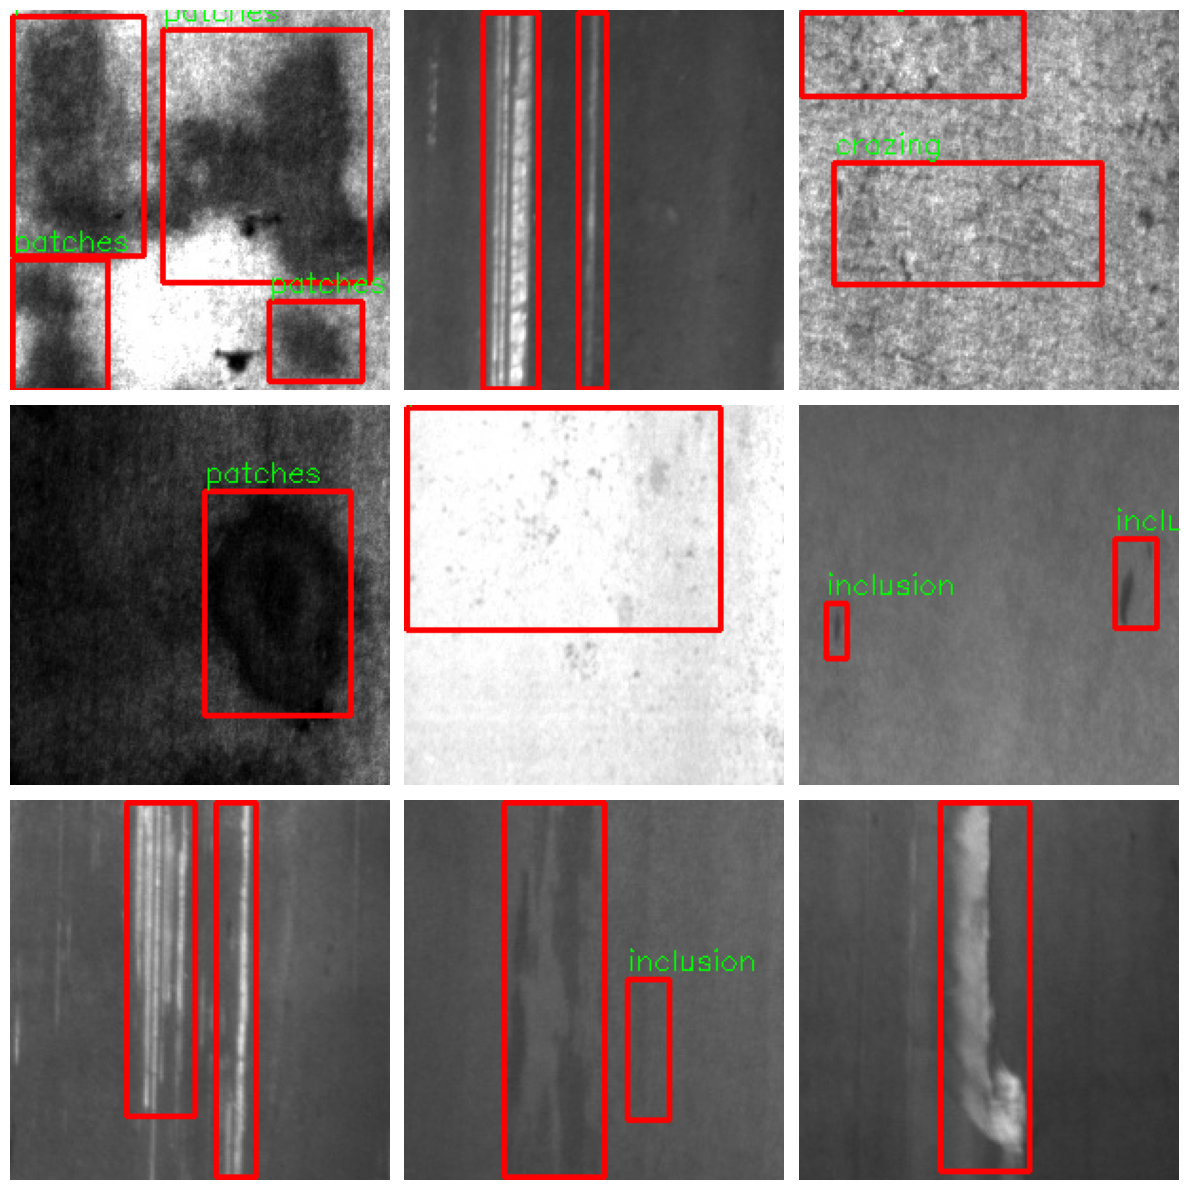

In [51]:
import random
import cv2
import matplotlib.pyplot as plt

IMAGE_DIR = PROCESSED_DATASET/"train"/"images"
LABEL_DIR = PROCESSED_DATASET/"train"/"labels"

images = random.sample(
    list(IMAGE_DIR.glob("*.jpg")),
    9
)

plt.figure(figsize=(12,12))

for i, image_path in enumerate(images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    H, W = image.shape[:2]

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    with open(label_path) as f:

        for line in f:

            cls, x, y, w, h = map(float, line.split())

            xmin = int((x - w/2) * W)
            ymin = int((y - h/2) * H)

            xmax = int((x + w/2) * W)
            ymax = int((y + h/2) * H)

            cv2.rectangle(
                image,
                (xmin,ymin),
                (xmax,ymax),
                (255,0,0),
                2
            )

            cv2.putText(
                image,
                list(CLASS_MAP.keys())[int(cls)],
                (xmin,ymin-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0,255,0),
                1
            )

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [52]:
print("="*40)

for split in ["train", "validation"]:

    image_count = len(list((PROCESSED_DATASET/split/"images").glob("*.jpg")))

    label_count = len(list((PROCESSED_DATASET/split/"labels").glob("*.txt")))

    print(f"{split}")

    print(f"Images : {image_count}")

    print(f"Labels : {label_count}")

    print(f"Match  : {image_count == label_count}")

    print("-"*40)

train
Images : 1440
Labels : 1440
Match  : True
----------------------------------------
validation
Images : 360
Labels : 360
Match  : True
----------------------------------------


In [53]:
train_images = {
    p.stem
    for p in (PROCESSED_DATASET/"train"/"images").glob("*.jpg")
}

train_labels = {
    p.stem
    for p in (PROCESSED_DATASET/"train"/"labels").glob("*.txt")
}

print("="*60)
print("TRAIN")
print("="*60)

print("\nImages without labels:")
print(train_images - train_labels)

print("\nLabels without images:")
print(train_labels - train_images)


val_images = {
    p.stem
    for p in (PROCESSED_DATASET/"validation"/"images").glob("*.jpg")
}

val_labels = {
    p.stem
    for p in (PROCESSED_DATASET/"validation"/"labels").glob("*.txt")
}

print("\n\n"+"="*60)
print("VALIDATION")
print("="*60)

print("\nImages without labels:")
print(val_images - val_labels)

print("\nLabels without images:")
print(val_labels - val_images)

TRAIN

Images without labels:
set()

Labels without images:
set()


VALIDATION

Images without labels:
set()

Labels without images:
set()


In [54]:
from pathlib import Path

for split in ["train", "validation"]:

    image = RAW_DATASET / split / "images" / "crazing" / "crazing_240.jpg"
    xml = RAW_DATASET / split / "annotations" / "crazing_240.xml"

    print("="*40)
    print(split.upper())
    print("Image Exists :", image.exists())
    print("XML Exists   :", xml.exists())

TRAIN
Image Exists : True
XML Exists   : True
VALIDATION
Image Exists : False
XML Exists   : False
